In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pygam import LinearGAM, s, te
from arch import arch_model
from scipy.stats import t as student_t


In [4]:
PATH = "data/cex4WindDataInterpolated.csv"  # <- change if needed

df = pd.read_csv(PATH)

# time
df["t"] = pd.to_datetime(df["t"], errors="coerce")
df = df.sort_values("t").reset_index(drop=True)

# time features
df["hour"] = df["t"].dt.hour.astype(float)
df["sin_hour"] = np.sin(2*np.pi*df["hour"]/24.0)
df["cos_hour"] = np.cos(2*np.pi*df["hour"]/24.0)

toy = (df["t"].dt.dayofyear.astype(float) / 365.0) % 1.0
df["toy"] = toy
df["sin_toy"] = np.sin(2*np.pi*df["toy"])
df["cos_toy"] = np.cos(2*np.pi*df["toy"])


In [5]:
def sincos_deg(series_deg):
    ang = np.deg2rad(series_deg.astype(float) % 360.0)
    return np.sin(ang), np.cos(ang)

def time_split(df, train_frac=0.8):
    n = len(df)
    split = int(n * train_frac)
    return df.iloc[:split].copy(), df.iloc[split:].copy()

def ols_fit(X, y):
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return beta

def rmse(y, yhat):
    return float(np.sqrt(np.mean((y - yhat)**2)))

def mae(y, yhat):
    return float(np.mean(np.abs(y - yhat)))

def assert_finite(df_like, name="data"):
    arr = np.asarray(df_like)
    if not np.isfinite(arr).all():
        bad = np.where(~np.isfinite(arr))
        raise ValueError(f"{name} contains NaN/Inf at indices (showing first 5): {list(zip(bad[0][:5], bad[1][:5]))}")


In [6]:
def build_arx_df(df, k=1, use_pc=False, add_wswd=False, use_diurnal=True, use_seasonal=True):
    """
    y = p_{t+k}
    baseline X includes p_t
    optionally includes power-curve feature 'pc'
    optionally includes Ws/Wd (linear terms) if add_wswd=True
    """
    ws = f"Ws{k}"
    wd = f"Wd{k}"
    y = df["p"].shift(-k)

    X = pd.DataFrame({"const": 1.0, "p_t": df["p"].astype(float)})

    if use_pc:
        if "pc" not in df.columns:
            raise ValueError("pc feature not found; call add_powercurve_feature first.")
        X["pc"] = df["pc"].astype(float)

    if add_wswd:
        # simple linear terms (optional)
        sin_wd, cos_wd = sincos_deg(df[wd])
        X["Ws"] = df[ws].astype(float)
        X["Ws2"] = (df[ws].astype(float))**2
        X["sinWd"] = sin_wd
        X["cosWd"] = cos_wd

    if use_diurnal:
        X["sin_hour"] = df["sin_hour"]
        X["cos_hour"] = df["cos_hour"]

    if use_seasonal:
        X["sin_toy"] = df["sin_toy"]
        X["cos_toy"] = df["cos_toy"]

    data = pd.concat([y.rename("y"), X], axis=1)
    data = data.replace([np.inf, -np.inf], np.nan).dropna()
    return data


In [7]:
def fit_powercurve_gam(df_train, k=1, lam_grid=None):
    ws = f"Ws{k}"
    wd = f"Wd{k}"
    if lam_grid is None:
        lam_grid = np.logspace(-3, 3, 9)

    # y = p_{t+k}
    y = df_train["p"].shift(-k)

    sin_wd, cos_wd = sincos_deg(df_train[wd])
    X = np.column_stack([df_train[ws].astype(float), sin_wd, cos_wd])

    tmp = pd.DataFrame(X, columns=["Ws","sinWd","cosWd"])
    tmp["y"] = y
    tmp = tmp.replace([np.inf, -np.inf], np.nan).dropna()

    Xn = tmp[["Ws","sinWd","cosWd"]].to_numpy()
    yn = tmp["y"].to_numpy()

    gam = LinearGAM(
        s(0, n_splines=25, spline_order=3) +
        te(0, 1, n_splines=[20, 10], spline_order=[3, 3]) +
        te(0, 2, n_splines=[20, 10], spline_order=[3, 3])
    )

    gam.gridsearch(Xn, yn, lam=lam_grid)
    return gam

def add_powercurve_feature(df_any, gam, k=1):
    ws = f"Ws{k}"
    wd = f"Wd{k}"

    sin_wd, cos_wd = sincos_deg(df_any[wd])
    X = np.column_stack([df_any[ws].astype(float), sin_wd, cos_wd])

    pc = np.full(len(df_any), np.nan)
    valid = np.all(np.isfinite(X), axis=1)
    pc[valid] = gam.predict(X[valid])

    out = df_any.copy()
    out["pc"] = pc
    return out


In [8]:
df_train, df_test = time_split(df, train_frac=0.8)
print("Train:", df_train["t"].iloc[0], "→", df_train["t"].iloc[-1])
print("Test :", df_test["t"].iloc[0],  "→", df_test["t"].iloc[-1])

results = []
artifacts = {}  # store models, betas, residuals, etc.

for k in [1,2,3]:
    # ---- fit power curve on train only ----
    gam = fit_powercurve_gam(df_train, k=k)
    df_train_k = add_powercurve_feature(df_train, gam, k=k)
    df_test_k  = add_powercurve_feature(df_test,  gam, k=k)

    # ---- baseline ARX (no pc) ----
    tr0 = build_arx_df(df_train_k, k=k, use_pc=False, add_wswd=False, use_diurnal=True, use_seasonal=True)
    te0 = build_arx_df(df_test_k,  k=k, use_pc=False, add_wswd=False, use_diurnal=True, use_seasonal=True)

    X_tr0 = tr0.drop(columns="y").to_numpy()
    y_tr0 = tr0["y"].to_numpy()
    X_te0 = te0.drop(columns="y").to_numpy()
    y_te0 = te0["y"].to_numpy()

    assert_finite(X_tr0, f"X_tr0(k={k})"); assert_finite(y_tr0, f"y_tr0(k={k})")
    assert_finite(X_te0, f"X_te0(k={k})"); assert_finite(y_te0, f"y_te0(k={k})")

    beta0 = ols_fit(X_tr0, y_tr0)
    yhat0 = X_te0 @ beta0

    results.append({"k": k, "model": "ARX(p_t + diurnal + seasonal)", "rmse": rmse(y_te0, yhat0), "mae": mae(y_te0, yhat0)})

    # ---- ARX + Power Curve (pc only; no Ws/Wd linear terms) ----
    tr1 = build_arx_df(df_train_k, k=k, use_pc=True, add_wswd=False, use_diurnal=True, use_seasonal=True)
    te1 = build_arx_df(df_test_k,  k=k, use_pc=True, add_wswd=False, use_diurnal=True, use_seasonal=True)

    X_tr1 = tr1.drop(columns="y").to_numpy()
    y_tr1 = tr1["y"].to_numpy()
    X_te1 = te1.drop(columns="y").to_numpy()
    y_te1 = te1["y"].to_numpy()

    assert_finite(X_tr1, f"X_tr1(k={k})"); assert_finite(y_tr1, f"y_tr1(k={k})")
    assert_finite(X_te1, f"X_te1(k={k})"); assert_finite(y_te1, f"y_te1(k={k})")

    beta1 = ols_fit(X_tr1, y_tr1)
    mu1 = X_te1 @ beta1
    yhat1 = mu1

    results.append({"k": k, "model": "ARX(p_t + pc + diurnal + seasonal)", "rmse": rmse(y_te1, yhat1), "mae": mae(y_te1, yhat1)})

    # store artifacts for later residual analysis / GARCH
    artifacts[k] = {
        "gam_pc": gam,
        "df_train_k": df_train_k,
        "df_test_k": df_test_k,
        "baseline": {"train": tr0, "test": te0, "beta": beta0, "yhat": yhat0},
        "pc":       {"train": tr1, "test": te1, "beta": beta1, "mu": mu1, "yhat": yhat1},
    }

res_df = pd.DataFrame(results).sort_values(["k","rmse"])
res_df


  0% (0 of 9) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--


Train: 1999-01-01 03:00:00 → 2002-06-18 18:00:00
Test : 2002-06-18 19:00:00 → 2003-04-30 23:00:00


 11% (1 of 9) |##                        | Elapsed Time: 0:00:04 ETA:   0:00:38
 22% (2 of 9) |#####                     | Elapsed Time: 0:00:08 ETA:   0:00:31
 33% (3 of 9) |########                  | Elapsed Time: 0:00:12 ETA:   0:00:25
 44% (4 of 9) |###########               | Elapsed Time: 0:00:16 ETA:   0:00:21
 55% (5 of 9) |##############            | Elapsed Time: 0:00:21 ETA:   0:00:16
 66% (6 of 9) |#################         | Elapsed Time: 0:00:24 ETA:   0:00:12
 77% (7 of 9) |####################      | Elapsed Time: 0:00:28 ETA:   0:00:08
 88% (8 of 9) |#######################   | Elapsed Time: 0:00:32 ETA:   0:00:04
100% (9 of 9) |##########################| Elapsed Time: 0:00:37 Time:  0:00:37
  0% (0 of 9) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
 11% (1 of 9) |##                        | Elapsed Time: 0:00:04 ETA:   0:00:33
 22% (2 of 9) |#####                     | Elapsed Time: 0:00:08 ETA:   0:00:28
 33% (3 of 9) |########                 

,k,model,rmse,mae
1,1,ARX(p_t + pc + diurnal + seasonal),1.470722,0.940473
0,1,ARX(p_t + diurnal + seasonal),1.504823,0.976713
3,2,ARX(p_t + pc + diurnal + seasonal),2.146648,1.420670
2,2,ARX(p_t + diurnal + seasonal),2.226186,1.508153
5,3,ARX(p_t + pc + diurnal + seasonal),2.605694,1.765703
4,3,ARX(p_t + diurnal + seasonal),2.714218,1.896059


Residual mean: -0.050051442768141004
Residual std : 1.469870569813404


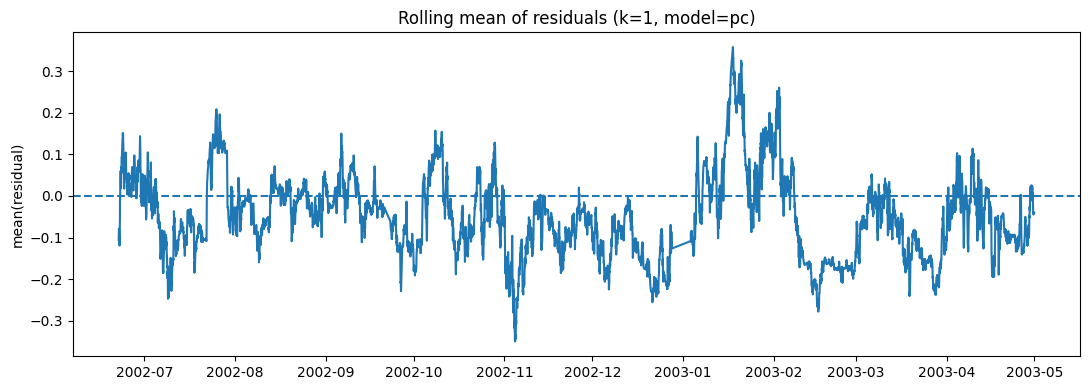

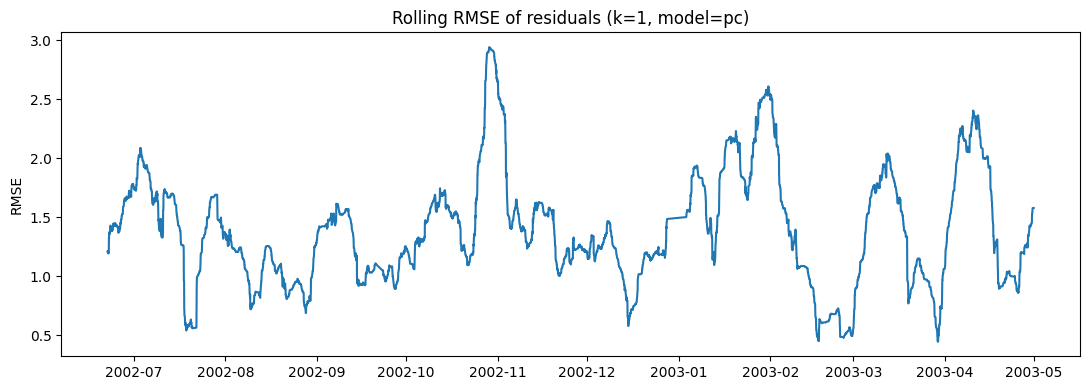

In [9]:
k = 1
which = "pc"  # "baseline" or "pc"

te = artifacts[k][which]["test"]
beta = artifacts[k][which]["beta"]
X_te = te.drop(columns="y").to_numpy()
y_te = te["y"].to_numpy()
mu_te = X_te @ beta
resid = y_te - mu_te

# map to timestamps: align with df_test_k index after dropna
df_test_k = artifacts[k]["df_test_k"]
t_idx = df_test_k.loc[te.index, "t"]

res = pd.Series(resid, index=t_idx)

print("Residual mean:", float(res.mean()))
print("Residual std :", float(res.std(ddof=0)))

# rolling diagnostics
win = 24*7  # 7 days
roll_mean = res.rolling(win, min_periods=win//2).mean()
roll_rmse = np.sqrt((res**2).rolling(win, min_periods=win//2).mean())

plt.figure(figsize=(11,4))
plt.plot(roll_mean.index, roll_mean.values)
plt.axhline(0, linestyle="--")
plt.title(f"Rolling mean of residuals (k={k}, model={which})")
plt.ylabel("mean(residual)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11,4))
plt.plot(roll_rmse.index, roll_rmse.values)
plt.title(f"Rolling RMSE of residuals (k={k}, model={which})")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()


                          Zero Mean - GARCH Model Results                           
Dep. Variable:                            y   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -46362.9
Distribution:      Standardized Student's t   AIC:                           92733.9
Method:                  Maximum Likelihood   BIC:                           92767.0
                                              No. Observations:                28895
Date:                      Wed, Dec 17 2025   Df Residuals:                    28895
Time:                              21:08:27   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omeg

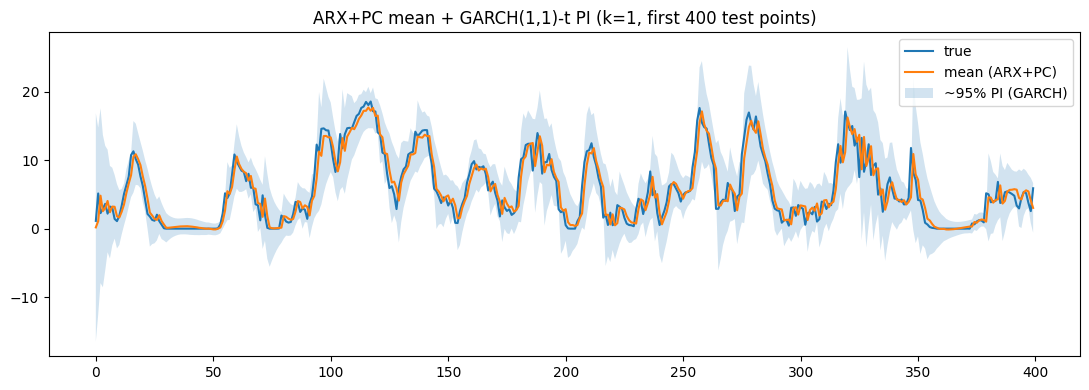

In [11]:
k = 1
which = "pc"  # fit volatility on residuals from this mean model

# ---- train residuals ----
tr = artifacts[k][which]["train"]
beta = artifacts[k][which]["beta"]

X_tr = tr.drop(columns="y").to_numpy()
y_tr = tr["y"].to_numpy()
mu_tr = X_tr @ beta
res_tr = y_tr - mu_tr

# demean for GARCH mean="Zero"
e_tr = res_tr - res_tr.mean()

am = arch_model(e_tr, mean="Zero", vol="GARCH", p=1, q=1, dist="t")
fit = am.fit(disp="off")
print(fit.summary())

# ---- test residuals / mean ----
te = artifacts[k][which]["test"]
X_te = te.drop(columns="y").to_numpy()
y_te = te["y"].to_numpy()
mu_te = X_te @ beta
res_te = y_te - mu_te

# ---- volatility recursion on test ----
params = fit.params
omega = float(params["omega"])
alpha = float(params["alpha[1]"])
beta_g = float(params["beta[1]"])
nu = float(params["nu"])  # Student-t df

# init with last train conditional variance
sigma2_last = float(fit.conditional_volatility[-1]**2)
e_last = float(e_tr[-1])

sigmas_te = np.zeros_like(res_te, dtype=float)

for i in range(len(res_te)):
    sigma2_last = omega + alpha*(e_last**2) + beta_g*sigma2_last
    sigmas_te[i] = np.sqrt(sigma2_last)
    # update with realized residual (one-step-ahead recursion)
    e_last = float(res_te[i] - res_tr.mean())

# ---- 95% PI using t-quantile ----
q = float(student_t.ppf(0.975, df=nu))
lower = mu_te - q * sigmas_te
upper = mu_te + q * sigmas_te

coverage = float(np.mean((y_te >= lower) & (y_te <= upper)))
avg_width = float(np.mean(upper - lower))

print(f"Empirical 95% PI coverage: {coverage:.3f}")
print(f"Average PI width: {avg_width:.3f}")

# plot first 400 test points
nplot = 400
plt.figure(figsize=(11,4))
plt.plot(y_te[:nplot], label="true")
plt.plot(mu_te[:nplot], label="mean (ARX+PC)")
plt.fill_between(np.arange(nplot), lower[:nplot], upper[:nplot], alpha=0.2, label="~95% PI (GARCH)")
plt.title(f"ARX+PC mean + GARCH(1,1)-t PI (k={k}, first {nplot} test points)")
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
garch_rows = []

for k in [1,2,3]:
    which = "pc"

    tr = artifacts[k][which]["train"]
    te = artifacts[k][which]["test"]
    beta = artifacts[k][which]["beta"]

    X_tr = tr.drop(columns="y").to_numpy()
    y_tr = tr["y"].to_numpy()
    mu_tr = X_tr @ beta
    res_tr = y_tr - mu_tr
    e_tr = res_tr - res_tr.mean()

    am = arch_model(e_tr, mean="Zero", vol="GARCH", p=1, q=1, dist="t")
    fit = am.fit(disp="off")

    X_te = te.drop(columns="y").to_numpy()
    y_te = te["y"].to_numpy()
    mu_te = X_te @ beta
    res_te = y_te - mu_te

    params = fit.params
    omega = float(params["omega"])
    alpha = float(params["alpha[1]"])
    beta_g = float(params["beta[1]"])
    nu = float(params["nu"])

    sigma2_last = float(fit.conditional_volatility[-1]**2)
    e_last = float(e_tr[-1])

    sigmas_te = np.zeros_like(res_te, dtype=float)
    for i in range(len(res_te)):
        sigma2_last = omega + alpha*(e_last**2) + beta_g*sigma2_last
        sigmas_te[i] = np.sqrt(sigma2_last)
        e_last = float(res_te[i] - res_tr.mean())

    q = float(student_t.ppf(0.975, df=nu))
    lower = mu_te - q * sigmas_te
    upper = mu_te + q * sigmas_te

    coverage = float(np.mean((y_te >= lower) & (y_te <= upper)))
    avg_width = float(np.mean(upper - lower))

    garch_rows.append({
        "k": k,
        "coverage_95": coverage,
        "avg_PI_width": avg_width,
        "omega": omega,
        "alpha": alpha,
        "beta": beta_g,
        "alpha+beta": alpha + beta_g,
        "nu": nu
    })

pd.DataFrame(garch_rows)


/var/folders/_m/4mgxhcdj4ns7lfq1pc_xf_3h0000gn/T/ipykernel_88781/2309295184.py:17: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  fit = am.fit(disp="off")
/var/folders/_m/4mgxhcdj4ns7lfq1pc_xf_3h0000gn/T/ipykernel_88781/2309295184.py:17: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  fit = am.fit(disp="off")


,k,coverage_95,avg_PI_width,omega,alpha,beta,alpha+beta,nu
0,1,0.965200,6.523996,0.032303,0.335437,0.664563,1.000000,4.572084
1,2,0.963966,8.534130,0.143083,0.470829,0.529190,1.000019,6.691244
2,3,0.963681,9.728346,0.349225,0.603832,0.396179,1.000011,9.396956
